In [2]:
import torch
import torch.nn as nn
import numpy as np

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [3]:

with open("/content/sample_data/input.txt", "r", encoding="utf-8") as f:
    text = f.read().lower()

print("Length of text:", len(text))

Length of text: 4494


## Creating Character Vocabulary & Vectorizing Text

In [4]:
# character vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)

print("Vocabulary Size:", vocab_size)

# Character to Index mapping
char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for ch, i in char2idx.items()}

# Converting entire text to integer indices
encoded_text = np.array([char2idx[ch] for ch in text])

Vocabulary Size: 32


## Creating Training Sequences

In [5]:
sequence_length = 50
step = 1

inputs = []
targets = []

for i in range(0, len(encoded_text) - sequence_length, step):
    inputs.append(encoded_text[i:i+sequence_length])
    targets.append(encoded_text[i+sequence_length])

X = np.array(inputs)
y = np.array(targets)

print("Total sequences:", len(X))

Total sequences: 4444


## Converting to Tensors

In [6]:
X = torch.tensor(X, dtype=torch.long).to(device)
y = torch.tensor(y, dtype=torch.long).to(device)

## RNN Model

In [30]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers):
        super(RNNModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out

In [54]:
rnn_losses = []
lstm_losses = []

## Train the Model

In [57]:


def train_model(model, X, y, epochs=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    criterion = nn.CrossEntropyLoss()
    loss_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        outputs = model(X)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

    return loss_history

In [67]:
model_rnn = RNNModel(vocab_size, 128, 2).to(device)
rnn_losses = train_model(model_rnn, X, y)

Epoch [1/100], Loss: 3.4932
Epoch [2/100], Loss: 3.3006
Epoch [3/100], Loss: 3.1225
Epoch [4/100], Loss: 2.9658
Epoch [5/100], Loss: 2.8616
Epoch [6/100], Loss: 2.7922
Epoch [7/100], Loss: 2.7279
Epoch [8/100], Loss: 2.6612
Epoch [9/100], Loss: 2.5989
Epoch [10/100], Loss: 2.5466
Epoch [11/100], Loss: 2.5027
Epoch [12/100], Loss: 2.4621
Epoch [13/100], Loss: 2.4220
Epoch [14/100], Loss: 2.3825
Epoch [15/100], Loss: 2.3449
Epoch [16/100], Loss: 2.3096
Epoch [17/100], Loss: 2.2768
Epoch [18/100], Loss: 2.2463
Epoch [19/100], Loss: 2.2180
Epoch [20/100], Loss: 2.1914
Epoch [21/100], Loss: 2.1659
Epoch [22/100], Loss: 2.1415
Epoch [23/100], Loss: 2.1178
Epoch [24/100], Loss: 2.0948
Epoch [25/100], Loss: 2.0723
Epoch [26/100], Loss: 2.0503
Epoch [27/100], Loss: 2.0283
Epoch [28/100], Loss: 2.0065
Epoch [29/100], Loss: 1.9848
Epoch [30/100], Loss: 1.9635
Epoch [31/100], Loss: 1.9424
Epoch [32/100], Loss: 1.9214
Epoch [33/100], Loss: 1.9004
Epoch [34/100], Loss: 1.8795
Epoch [35/100], Loss: 1

## LSTM Model

In [59]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers):
        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

## Train the Model



In [68]:
model_lstm = LSTMModel(vocab_size, 128, 2).to(device)
lstm_losses = train_model(model_lstm, X, y)

Epoch [1/100], Loss: 3.4540
Epoch [2/100], Loss: 3.4110
Epoch [3/100], Loss: 3.3521
Epoch [4/100], Loss: 3.2548
Epoch [5/100], Loss: 3.1208
Epoch [6/100], Loss: 3.0437
Epoch [7/100], Loss: 3.0334
Epoch [8/100], Loss: 3.0105
Epoch [9/100], Loss: 2.9813
Epoch [10/100], Loss: 2.9609
Epoch [11/100], Loss: 2.9515
Epoch [12/100], Loss: 2.9453
Epoch [13/100], Loss: 2.9358
Epoch [14/100], Loss: 2.9220
Epoch [15/100], Loss: 2.9050
Epoch [16/100], Loss: 2.8866
Epoch [17/100], Loss: 2.8683
Epoch [18/100], Loss: 2.8501
Epoch [19/100], Loss: 2.8321
Epoch [20/100], Loss: 2.8133
Epoch [21/100], Loss: 2.7929
Epoch [22/100], Loss: 2.7705
Epoch [23/100], Loss: 2.7466
Epoch [24/100], Loss: 2.7224
Epoch [25/100], Loss: 2.6976
Epoch [26/100], Loss: 2.6721
Epoch [27/100], Loss: 2.6463
Epoch [28/100], Loss: 2.6200
Epoch [29/100], Loss: 2.5932
Epoch [30/100], Loss: 2.5660
Epoch [31/100], Loss: 2.5389
Epoch [32/100], Loss: 2.5119
Epoch [33/100], Loss: 2.4855
Epoch [34/100], Loss: 2.4596
Epoch [35/100], Loss: 2

## Text Generation Function

In [69]:
def generate_text(model, start_text, length=200):
    model.eval()

    input_seq = torch.tensor([char2idx[ch] for ch in start_text], dtype=torch.long).unsqueeze(0).to(device)

    generated = start_text

    for _ in range(length):
        output = model(input_seq)
        prob = torch.softmax(output, dim=1).detach().cpu().numpy()
        next_char = np.random.choice(vocab_size, p=prob[0])

        generated += idx2char[next_char]

        input_seq = torch.cat(
            [input_seq[:, 1:], torch.tensor([[next_char]]).to(device)],
            dim=1
        )

    return generated

## Generate New Text & Validate

### Using RNN

In [70]:
start = "In football we need to understand "
generated_text = generate_text(model_rnn, start.lower(), 1000)

print("\nGenerated Text:\n")
print(generated_text)


Generated Text:

in football we need to understand can poact’en foomdelitial.
yrefien is optsting involvemently besive lootball is wart also mall, teaprerit the exceptions decisions ofssures to fiom uecis of s atfothes ancled to fuot involvement.

ay tecirver to camsured to preckersing inven ntes, offense the offside.
it en.
inerus mact considerent call gainillsed.

the offside carefuly be an offside rule ir cs the juma thepesserf teamficl conllagenthe fooxts may coiptar tompertens owtan in dy asse.
mofesse.
these exyemores stay of defensive id besichs teamkerp, the include djlente from a warptes determine.
it eupracizwirn jtingons.

to intensive line.
the imssoswagend internetitive hay ars attacking plageer playert fens ofwsken.
comojpently by ancare atss offside rule the opponently be apporingtel gove offside.
precisions incllveid to inder maintaid leath saming pescinse.
goief footbofess ond besult is alawser forward tockithe dipersinderdering of the offside interpretation second la

### Using LSTM

In [71]:
start = "In football we need to understand "
generated_text = generate_text(model_lstm, start.lower(), 1000)

print("\nGenerated Text:\n")
print(generated_text)


Generated Text:

in football we need to understand be lato.
define.
forusing ays defenlies moottbeve forcer the surkes ancoes tuatten precisimeep the offside, opato.ite, presiveend the canmentwand ams.
the refereevesime forver play oret regmeains.
the.

in as colpplial.
 passis hat.
it inalulced muscas.

atick yruns off interfigen refaing the an off dillavay osetray.
it palt. an ofbbathe carevule the offside decesmilmen.
lay in temaincing.

it pla.
in opthe banican ouvoment time the conterprinh ofpite kiens vaed thew ad defsions coale th plymit, to prentang offside demains of intenategins ant offense mret ethelligend reversdetestiphurrate pars to the mevay a plises.
ig an interppocy ogtech tousgine cpplay alge stioll mmoders the offneneserr proven actinn, emplaysy dewover otk play.y ingveres, oved a slaigse.
the yootfion aly.
beo an cinaludging offsing porame tay  ictions azed colllvede derings ofty famis a larecg offsigefdere sirrelos ide sisp.pry balcs of the corextentes a thee denc

## Loss vs Epoch

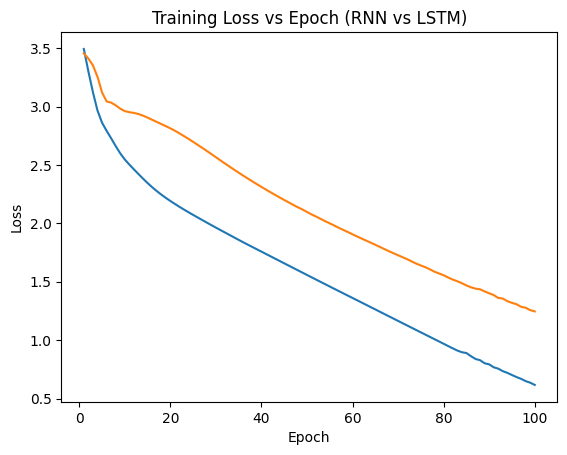

In [72]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, len(rnn_losses)+1)

plt.figure()
plt.plot(epochs, rnn_losses)
plt.plot(epochs, lstm_losses)
plt.title("Training Loss vs Epoch (RNN vs LSTM)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Perplexity vs Epoch

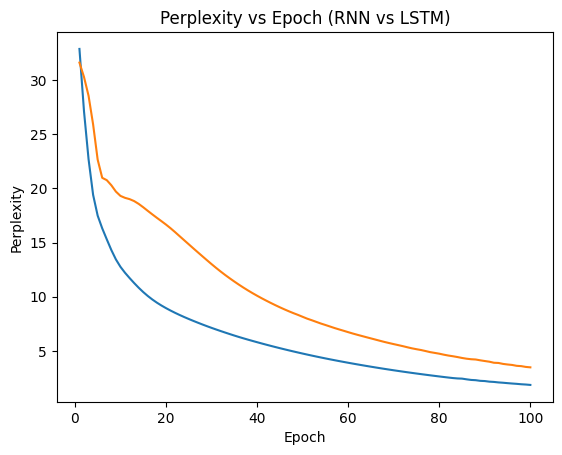

In [73]:
rnn_perplexity = np.exp(rnn_losses)
lstm_perplexity = np.exp(lstm_losses)

plt.figure()
plt.plot(epochs, rnn_perplexity)
plt.plot(epochs, lstm_perplexity)
plt.title("Perplexity vs Epoch (RNN vs LSTM)")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.show()

## Embedding Visualization using PCA

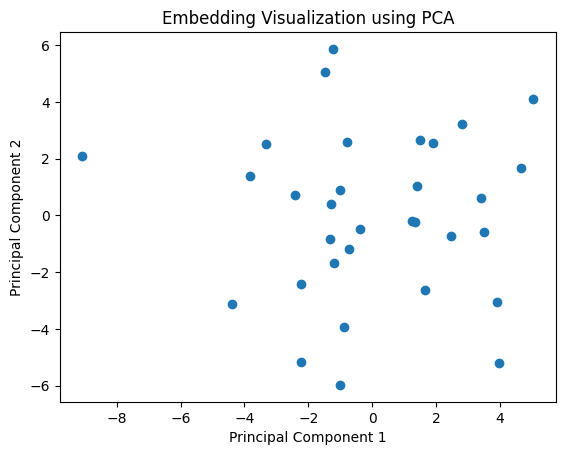

In [74]:
from sklearn.decomposition import PCA

# Get embedding weights from LSTM model
embeddings = model_lstm.embedding.weight.detach().cpu().numpy()

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure()
plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1])
plt.title("Embedding Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

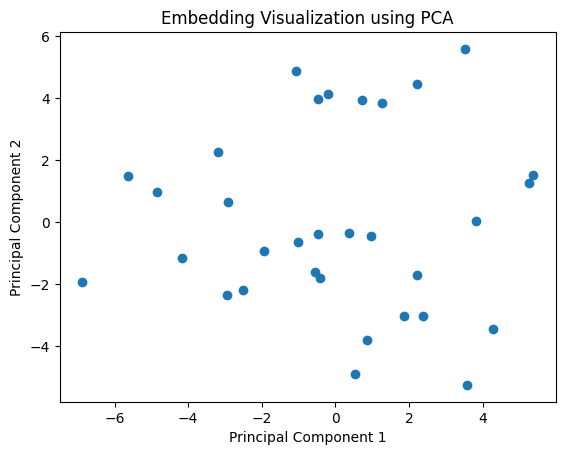

In [75]:
from sklearn.decomposition import PCA

# Get embedding weights from RNN model
embeddings =model_rnn.embedding.weight.detach().cpu().numpy()

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure()
plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1])
plt.title("Embedding Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## Hidden State Activation Visualization

In [76]:
def get_hidden_states(model, input_sample):
    model.eval()
    with torch.no_grad():
        x = model.embedding(input_sample)
        h0 = torch.zeros(model.num_layers, x.size(0), model.hidden_size).to(device)

        if isinstance(model, LSTMModel):
            c0 = torch.zeros(model.num_layers, x.size(0), model.hidden_size).to(device)
            out, (hn, cn) = model.lstm(x, (h0, c0))
        else:
            out, hn = model.rnn(x, h0)

    return out.squeeze(0).cpu().numpy()

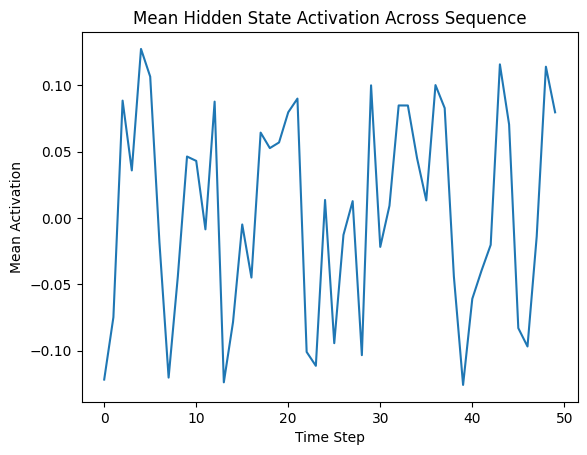

In [79]:
sample_input = X[0].unsqueeze(0)
hidden_states = get_hidden_states(model_rnn, sample_input)

mean_activation = hidden_states.mean(axis=1)

plt.figure()
plt.plot(mean_activation)
plt.title("Mean Hidden State Activation Across Sequence")
plt.xlabel("Time Step")
plt.ylabel("Mean Activation")
plt.show()

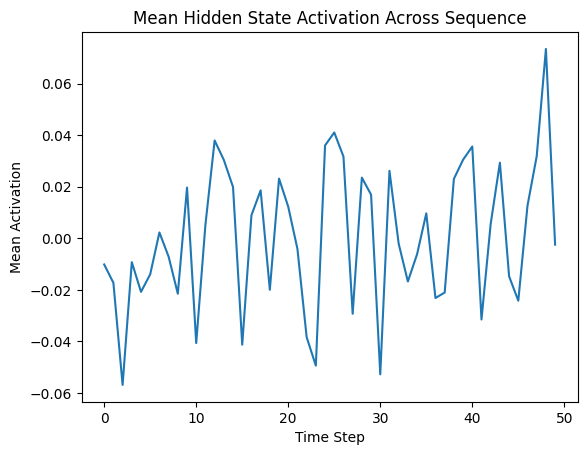

In [77]:
sample_input = X[0].unsqueeze(0)
hidden_states = get_hidden_states(model_lstm, sample_input)

mean_activation = hidden_states.mean(axis=1)

plt.figure()
plt.plot(mean_activation)
plt.title("Mean Hidden State Activation Across Sequence")
plt.xlabel("Time Step")
plt.ylabel("Mean Activation")
plt.show()